In [35]:
import numpy as np 
import pandas as pd 
from itertools import product 
import matplotlib.pyplot as plt 
from sklearn.metrics import ndcg_score

In [2]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'../predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds = df_preds.loc[df_preds.adm_1 != 32]
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [3]:
def get_data(name = 'dengue_state'): 

    df = pd.read_csv(f'../data/{name}.csv.gz')

    return df

In [4]:
df_dengue_state = get_data('dengue_state')

df_dengue_state.date = pd.to_datetime(df_dengue_state.date)

df_dengue_state = df_dengue_state.loc[df_dengue_state.adm_1 != 32]


df_dengue_state.head()

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115


Ranks: 

In [5]:
df_rk_1 = pd.read_csv('default_rk_1.csv.gz')
df_rk_2 = pd.read_csv('norm_rk_2.csv.gz')
df_rk_3 = pd.read_csv('diff_rk_3.csv.gz')
df_rk_4 = pd.read_csv('mean_rk_4.csv.gz')

In [23]:
def get_ndgc_score(df_preds, df_rk_1, label): 

    df_rk_1 = df_rk_1.loc[df_rk_1.adm_1 != 32] 

    list_dfs = [] 

    for adm, val in product(df_rk_1.adm_1.unique(), [1,2,3,4]): 
    
        df_m = df_preds.loc[(df_preds.adm_1 == adm) & (df_preds.validation == val) ].drop_duplicates(subset=['adm_1',
                                            'validation', 'wis'])[['adm_1', 'validation', 
                                            'wis', 'model']].merge(df_rk_1[['model', 'adm_1', 'rank']], on = ['model', 'adm_1'])

        df_m['rel'] = 1/df_m['wis']

        y_true = df_m['rel']

        y_score = -df_m['rank']

        ndcg = ndcg_score([y_true], [y_score])

        list_dfs.append(pd.DataFrame([[adm, val, ndcg]], columns = ['adm_1', 'validation', 'ndcg' ]))


    df_ndcg = pd.concat(list_dfs, ignore_index= True )

    df_ndcg['rank'] = label

    return df_ndcg

In [24]:
df_ndcg_end = pd.DataFrame()

for df_rank, label in zip([df_rk_1, df_rk_2, df_rk_3, df_rk_4], ['rk_1', 'rk_2', 'rk_3', 'rk_4']): 
  
    df_ndcg = get_ndgc_score(df_preds, df_rank, label = label)

    df_ndcg_end = pd.concat([df_ndcg_end, df_ndcg], ignore_index = True)

df_ndcg_end.head()

,adm_1,validation,ndcg,rank
0,14,1,0.916900,rk_1
1,14,2,0.970696,rk_1
2,14,3,0.903213,rk_1
3,14,4,0.970772,rk_1
4,28,1,0.971776,rk_1


In [28]:
method = 'rk_1'

In [39]:
def get_fig(ax, df_ndcg_end, method):

    df_ndcg_end.loc[df_ndcg_end['rank'] == method]['ndcg'].hist(ax=ax)

    ax.set_title(f'''{method}, median: {np.round(df_ndcg_end.loc[df_ndcg_end['rank'] == method]['ndcg'].median(), 2)}, mean: {np.round(df_ndcg_end.loc[df_ndcg_end['rank'] == method]['ndcg'].mean(), 2)}''') 

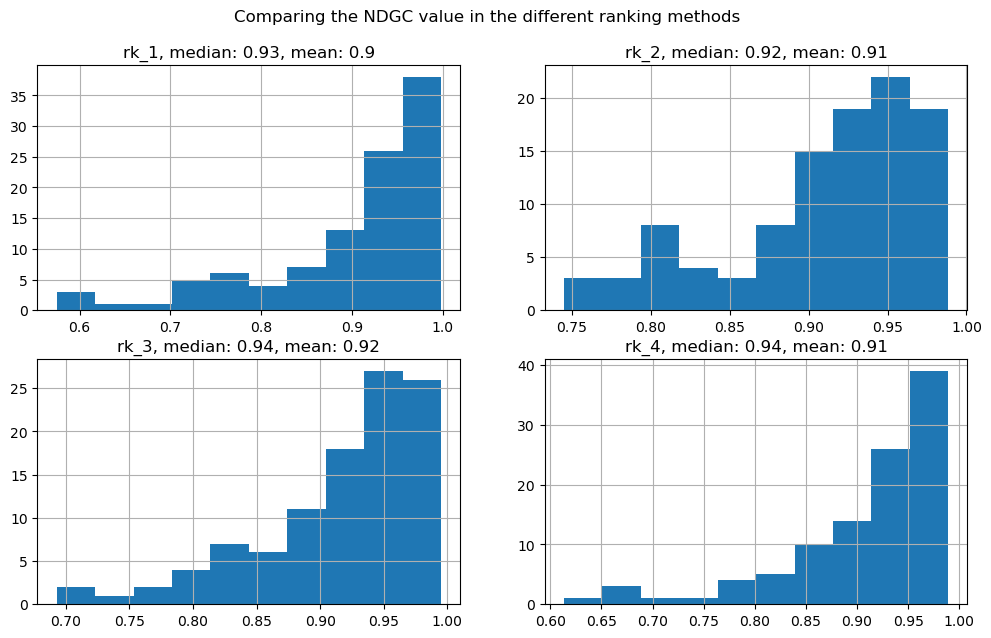

In [50]:
_,ax = plt.subplots(2,2, figsize = (12, 7))

get_fig(ax[0,0], df_ndcg_end, method = 'rk_1')
get_fig(ax[0,1], df_ndcg_end, method = 'rk_2')
get_fig(ax[1,0], df_ndcg_end, method = 'rk_3')
get_fig(ax[1,1], df_ndcg_end, method = 'rk_4')

plt.suptitle('Comparing the NDGC value in the different ranking methods', y = 0.96, fontsize = 12)

plt.savefig('comp_ndgc.png', dpi = 300, bbox_inches = 'tight')